In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

dt_clf = DecisionTreeClassifier(random_state = 42)

iris_data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state = 42)

dt_clf.fit(X_train, y_train);

In [71]:
from sklearn.tree import export_graphviz

export_graphviz(dt_clf, out_file = "tree.dot", class_names= iris_data.target_names, 
                feature_names = iris_data.feature_names, impurity = True, filled = True
                )

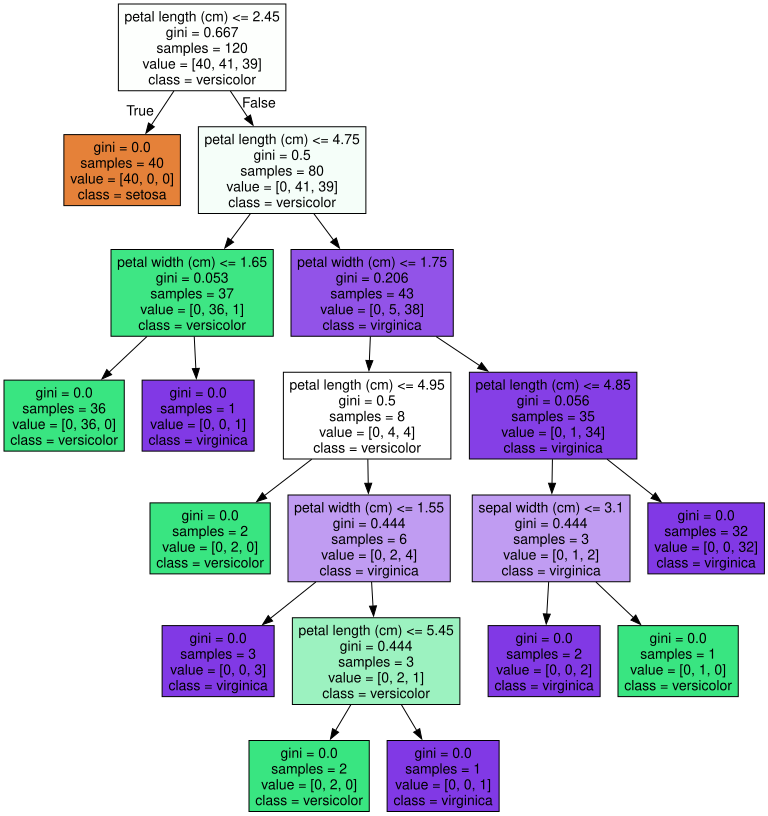

In [72]:
import graphviz

with open("./tree.dot") as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)

Feature Importance : 
[0.    0.017 0.906 0.077]
sepal length (cm) : 0.000000
sepal width (cm) : 0.016670
petal length (cm) : 0.906143
petal width (cm) : 0.077186


<Axes: >

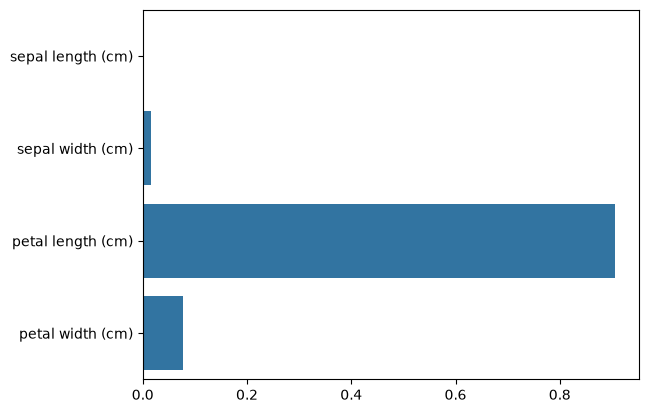

In [73]:
import seaborn as sns
import numpy as np

print("Feature Importance : \n{0}".format(np.round(dt_clf.feature_importances_, 3)))

for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
    print("{0} : {1:3f}".format(name,value))

sns.barplot(x = dt_clf.feature_importances_, y = iris_data.feature_names)

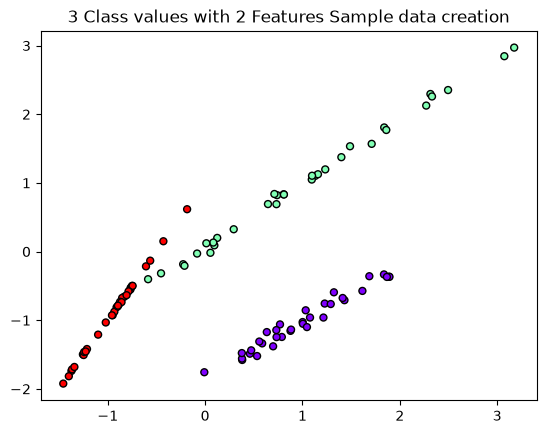

In [74]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

plt.title(
    "3 Class values with 2 Features Sample data creation"
)

X_features, y_labels = make_classification(
    n_features= 2,
    n_redundant = 0,
    n_informative = 2,
    n_classes = 3,
    n_clusters_per_class = 1,
    random_state = 42
)

plt.scatter(X_features[:, 0], X_features[:,1],marker = "o", c = y_labels, s = 25, cmap = "rainbow", edgecolor = "k")

In [75]:
import numpy as np

def visualize_boundary(model, X, y):
    fig, ax = plt.subplots()

    ax.scatter(X[:, 0], X[:, 1], c = y, s= 25, cmap = "rainbow", edgecolor = 'k',
               clim = (y.min(),y.max()), zorder = 3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start, xlim_end = ax.get_xlim()
    ylim_start, ylim_end = ax.get_ylim()

    model.fit(X,y)
    xx, yy = np.meshgrid(np.linspace(xlim_start, xlim_end, num= 20), np.linspace(ylim_start, ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3, levels = np.arange(n_classes + 1) -0.5, cmap = "rainbow", clim = (y.min(), y.max()), zorder = 1)

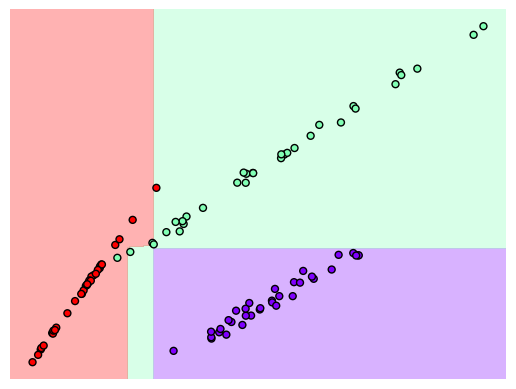

In [76]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state = 42).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

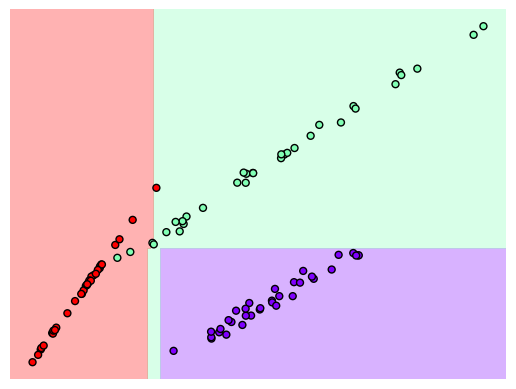

In [77]:
dt_clf = DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state = 42, min_samples_leaf = 6 ).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

In [78]:
import csv
import pandas as pd
import matplotlib.pyplot as plt

with open("./data/human_activity_train.csv",encoding = "utf-8") as f:
    header = next(csv.reader(f))

feature_name_org = header[:-2]

feature_name_df = pd.DataFrame({"column_index":range(1, len(feature_name_org)+1),
                                "column_name": feature_name_org })

feature_name = feature_name_df.iloc[:, 1].values.tolist()

print("전체 피처 개수:", len(feature_name))
print("전체 피처명에서 10개만", feature_name[:10])

전체 피처 개수: 561
전체 피처명에서 10개만 ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [79]:
feature_dup_df = feature_name_df.groupby("column_name").count() # 칼럼이름별로 그룹으로 모음 / 칼럼 중복되는게있으면 카운트가 1이상 될것임
print(feature_dup_df[feature_dup_df["column_index"]>1].count())
feature_dup_df[feature_dup_df["column_index"]>1].head()


column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [80]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data = old_feature_name_df.groupby("column_name").cumcount(),
                                  columns=["dup_cnt"])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(),
                                   feature_dup_df,
                                   how="outer")
    new_feature_name_df["column_name"] = new_feature_name_df[["column_name", "dup_cnt"]].apply(lambda x : x["column_name"]+'_'+str(x["dup_cnt"]) if x["dup_cnt"]>0 else x["column_name"], axis=1)

    new_feature_name_df = new_feature_name_df.drop(["index"],axis=1)
    return new_feature_name_df

In [81]:
import csv
import pandas as pd

ACTION_MAP = {"WALKING":1,
              "WALKING_UPSTAIRS":2,
              "WALKING_DOWNSTAIRS":3,
              "SITTING":4,
              "STANDING":5,
              "LAYING":6}

def get_human_dataset():
    train_file = "./data/human_activity_train.csv"
    test_file = "./data/human_activity_test.csv"

    with open(train_file, encoding="utf-8") as f:
        header = next(csv.reader(f))
    feature_name_org = header[:-2]
    feature_name_df = pd.DataFrame({"column_index": range(1,len(feature_name_org)+1),
                                    "column_name": feature_name_org})

    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()

    col_names = feature_name + ["subject", "action"]
    train_df = pd.read_csv(train_file, header = 0, names = col_names)
    test_df = pd.read_csv(test_file, header= 0, names=col_names)

    X_train = train_df[feature_name]
    X_test = test_df[feature_name]

    y_train = train_df["action"].replace(ACTION_MAP)
    y_test = test_df["action"].replace(ACTION_MAP)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()
print("X_train:", X_train.shape, "X_test:", X_test.shape,
          "y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (7352, 561) X_test: (2947, 561) y_train: (7352,) y_test: (2947,)


In [82]:
print("## 학습 피처 데이터셋 info()")
print(X_train.info())

## 학습 피처 데이터셋 info()
<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


In [83]:
print(y_train.value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


In [84]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


print(y_train.info())
dt_clf = DecisionTreeClassifier(random_state = 42)
dt_clf.fit(X_train, y_train.astype(int))
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test.astype(int), pred)

print(accuracy)

<class 'pandas.Series'>
RangeIndex: 7352 entries, 0 to 7351
Series name: action
Non-Null Count  Dtype 
--------------  ----- 
7352 non-null   object
dtypes: object(1)
memory usage: 57.6+ KB
None
0.8622327790973872


In [85]:
print(dt_clf.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [86]:
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth" : [6,8,10,12,16,20,24]
}

grid_cv = GridSearchCV(
    dt_clf,
    param_grid = params,
    scoring = "accuracy",
    cv = 5,
    verbose = 1
)

grid_cv.fit(X_train, y_train.astype(int))

print(grid_cv.best_score_)
print(grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
0.847940824188275
{'max_depth': 8}


In [87]:
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

cv_results_df[["param_max_depth","mean_test_score"]]

,param_max_depth,mean_test_score
0,6,0.846303
1,8,0.847941
2,10,0.840464
3,12,0.843319
4,16,0.845358
5,20,0.845086
6,24,0.847397


In [88]:
params = {
    "max_depth" : [8,12,16,20],
    "min_samples_split" : [16,24]
}
grid_cv = GridSearchCV(
    dt_clf,
    param_grid = params,
    scoring = "accuracy",
    cv = 5,
    verbose = 1
)
grid_cv.fit(X_train, y_train.astype(int))

print(grid_cv.best_score_)
print(grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
0.8509322641361099
{'max_depth': 8, 'min_samples_split': 24}


In [89]:
best_dt_clf = grid_cv.best_estimator_
pred1 = best_dt_clf.predict(X_test)
accuracy = accuracy_score(y_test.astype(int), pred1)
print(accuracy)

#예측한것에 대한 정확도 스코어 얻은것임. 정확도가 조금더 높게 나옴.

0.8686800135731252


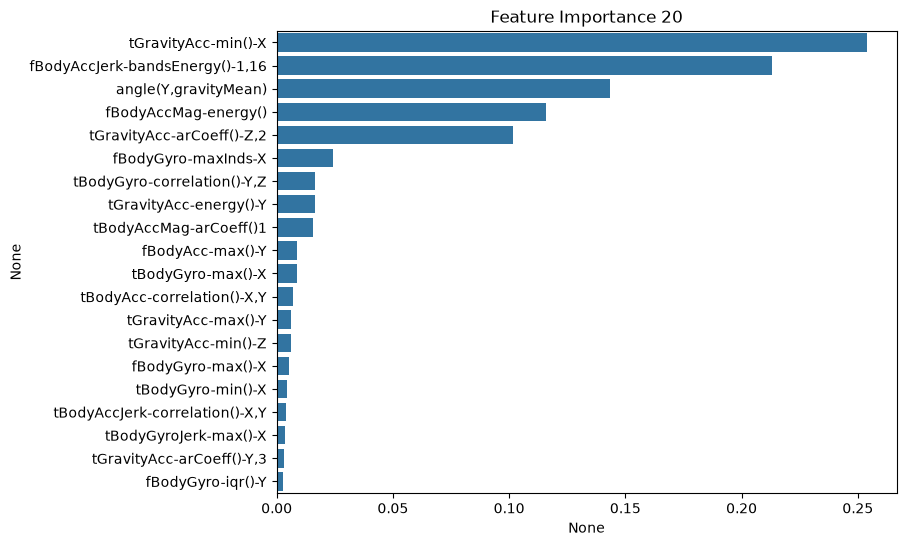

In [90]:
import seaborn as sns

ftr_importances_values = best_dt_clf.feature_importances_
ftr_importances = pd.Series(
    ftr_importances_values,
    index = X_train.columns
)
ftr_top20 = ftr_importances.sort_values(ascending = False)[:20]
plt.figure(figsize = (8,6))
plt.title("Feature Importance 20")
sns.barplot(x = ftr_top20, y = ftr_top20.index)
plt.show()

In [91]:
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns = cancer.feature_names)
data_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [92]:
lr_clf = LogisticRegression(solver = "liblinear")
knn_clf = KNeighborsClassifier(n_neighbors=8)

vo_clf = VotingClassifier(estimators = [
    ("LR",lr_clf),
    ("KNN", knn_clf)],
    voting = "soft"
)

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    test_size = 0.2,
    random_state = 42
)

vo_clf.fit(X_train,y_train)
pred = vo_clf.predict(X_test)
print(accuracy_score(y_test,pred))

0.9649122807017544


In [93]:
classifiers = [lr_clf, knn_clf]
for classifier in classifiers:
    classifier.fit(X_train, y_train)
    pred = classifier.predict(X_test)
    print(classifier.__class__.__name__, accuracy_score(y_test,pred))

LogisticRegression 0.956140350877193
KNeighborsClassifier 0.956140350877193


In [94]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data = old_feature_name_df.groupby("column_name").cumcount(),
                                  columns=["dup_cnt"])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(),
                                   feature_dup_df,
                                   how="outer")
    new_feature_name_df["column_name"] = new_feature_name_df[["column_name", "dup_cnt"]].apply(lambda x : x["column_name"]+'_'+str(x["dup_cnt"]) if x["dup_cnt"]>0 else x["column_name"], axis=1)

    new_feature_name_df = new_feature_name_df.drop(["index"],axis=1)
    return new_feature_name_df

In [95]:
import csv
import pandas as pd

ACTION_MAP = {"WALKING":1,
              "WALKING_UPSTAIRS":2,
              "WALKING_DOWNSTAIRS":3,
              "SITTING":4,
              "STANDING":5,
              "LAYING":6}

def get_human_dataset():
    train_file = "./data/human_activity_train.csv"
    test_file = "./data/human_activity_test.csv"

    with open(train_file, encoding="utf-8") as f:
        header = next(csv.reader(f))
    feature_name_org = header[:-2]
    feature_name_df = pd.DataFrame({"column_index": range(1,len(feature_name_org)+1),
                                    "column_name": feature_name_org})

    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()

    col_names = feature_name + ["subject", "action"]
    train_df = pd.read_csv(train_file, header = 0, names = col_names)
    test_df = pd.read_csv(test_file, header= 0, names=col_names)

    X_train = train_df[feature_name]
    X_test = test_df[feature_name]

    y_train = train_df["action"].replace(ACTION_MAP)
    y_test = test_df["action"].replace(ACTION_MAP)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()
print("X_train:", X_train.shape, "X_test:", X_test.shape,
          "y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (7352, 561) X_test: (2947, 561) y_train: (7352,) y_test: (2947,)


In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

X_train, X_test, y_train, y_test = get_human_dataset()

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train.astype(int))
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test.astype(int), pred)
print(accuracy)

0.9256871394638616


In [97]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[100],
    "max_depth" : [6,8,10,12],
    "min_samples_leaf" : [8,12,18],
    "min_samples_split" : [8,16,20]
}

rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf, param_grid = params, cv=2, n_jobs=-1)
grid_cv.fit(X_train, y_train.astype(int))

print(grid_cv.best_params_)
print(grid_cv.best_score_)


{'max_depth': 12, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}
0.9189336235038085


In [98]:
rf_clf1 = RandomForestClassifier(
    n_estimators= 300, 
    max_depth = 12, 
    min_samples_leaf = 8,
    min_samples_split = 8,
    random_state = 42
    )

rf_clf.fit(X_train, y_train.astype(int))
pred = rf_clf.predict(X_test)
print(accuracy_score(y_test.astype(int), pred))

0.9256871394638616


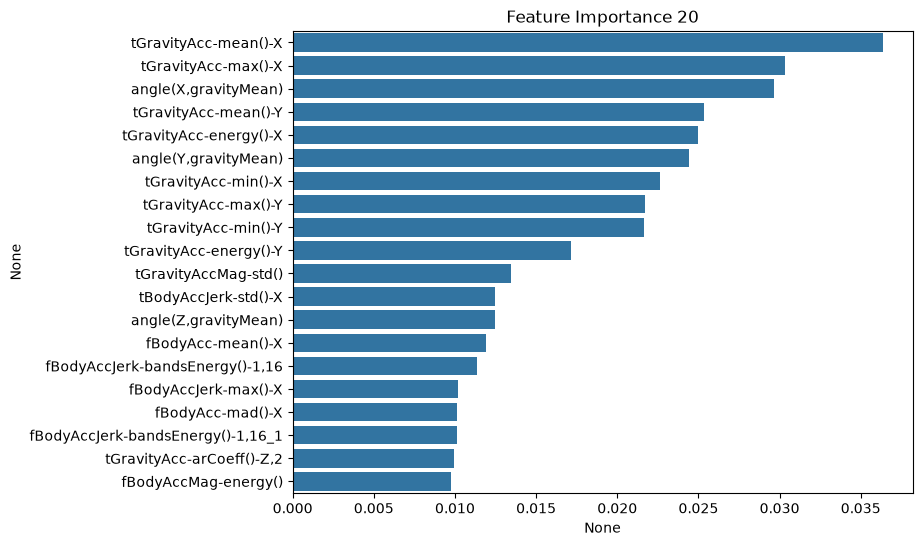

<Figure size 640x480 with 0 Axes>

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

ftr_importances_values = rf_clf.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index = X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending = False)[:20]

plt.figure(
    figsize = (8,6)
)
plt.title("Feature Importance 20")
sns.barplot(x = ftr_top20, y = ftr_top20.index)
fig1 = plt.gcf()
plt.show()
plt.draw()

In [102]:
from sklearn.ensemble import GradientBoostingClassifier
import time

X_train, X_test, y_train, y_test = get_human_dataset()

start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state = 42)
gb_clf.fit(X_train, y_train.astype(int))
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test.astype(int), gb_pred)

print(gb_accuracy)
print(time.time() - start_time)

0.9389209365456397
479.9432897567749
